Импорт нужных библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, precision_score, recall_score, f1_score

Загрузка датасета

In [94]:
df=pd.read_csv('S05-hw-dataset.csv')

Вывод первых пяти строчек таблицы

In [56]:
df.head()

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


Сводка о датасете

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

Описательная статистика

In [96]:
df.describe()

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,45.059667,69658.992000,19.577667,649.285333,0.284065,3.494667,6.869333,0.495000,0.501333,20607.256667,5559.684333,0.400175,9.524667,1.976333,6.968667,0.410333
std,866.169729,14.192883,24742.235182,11.381497,69.955852,0.161112,2.289917,4.291278,0.500058,0.500082,14035.209739,6306.032612,0.204529,5.779030,1.408700,4.349942,0.491976
min,1.000000,21.000000,15000.000000,0.000000,402.000000,0.006147,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.001148,0.000000,0.000000,0.000000,0.000000
25%,750.750000,33.000000,52641.750000,10.000000,604.000000,0.157796,1.000000,3.000000,0.000000,0.000000,9612.250000,341.500000,0.239208,5.000000,1.000000,3.000000,0.000000
50%,1500.500000,45.000000,69784.500000,20.000000,647.000000,0.261726,3.000000,7.000000,0.000000,1.000000,20021.000000,5114.500000,0.381992,10.000000,2.000000,7.000000,0.000000
75%,2250.250000,57.000000,85874.250000,29.000000,697.000000,0.388886,6.000000,10.000000,1.000000,1.000000,30101.250000,9906.250000,0.549213,15.000000,3.000000,11.000000,1.000000
max,3000.000000,69.000000,156351.000000,39.000000,850.000000,0.878343,7.000000,14.000000,1.000000,1.000000,75237.000000,29335.000000,0.961733,19.000000,4.000000,14.000000,1.000000


Распределение значений

In [97]:
df.value_counts(normalize=True)

,,,,,,,,,,,,,,,,,proportion
client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default,
3000,53,75302,13,692,0.093865,2,7,0,0,29853,1259,0.693861,6,2,9,0,0.000333
1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0,0.000333
2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0,0.000333
3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0,0.000333
4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1,0.000333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13,57,69664,3,539,0.319360,0,6,0,1,31063,6166,0.581045,4,3,4,1,0.000333
12,68,98126,12,648,0.187963,0,3,0,0,31947,-730,0.819837,7,4,3,0,0.000333
11,46,72737,20,632,0.134631,7,10,0,0,29784,5907,0.222156,4,1,12,0,0.000333


Всего 3000 клиентов, 15 признаков, нормально распределённый таргет

Матрица признаков и вектор таргета

In [98]:
y = df['default'].copy()
X = df.drop(columns=['default', 'client_id']).copy()

Разделение данных на обучающую и тестовую выборки

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Построение безлайн-модели

In [100]:
model = DummyClassifier(strategy="most_frequent", random_state=42)
model.fit(X_train, y_train)

DummyClassifier(random_state=42, strategy='most_frequent')

Оценка безлайн-модели по двум метрикам

In [101]:
y_pred_classes = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred_classes)
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print(f"accuracy: {accuracy:.4f}")
print(f"roc_auc_score: {roc_auc:.4f}")

accuracy: 0.5900
roc_auc_score: 0.5000


Бейзлайн-модель — простейшая модель-заглушка, которая всегда предсказывает самый частый класс в обучающих данных, является отправной точкой для сравнения и улучшения. Точка отсчёта нужна для определения минимального порога, оценки сложности задачи и контроля за адекватностью

Построение пайплайна, состоящего из стандартизации признаков и логистической регрессии, и вывод его метрик

In [135]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])

pipe.fit(X_train, y_train)


y_pred = pipe.predict(X_test)
y_pred_proba = pipe.predict_proba(X_test)[:, 1]


accuracy_val = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred, zero_division=0)
recall_val = recall_score(y_test, y_pred, zero_division=0)
f1_val = f1_score(y_test, y_pred, zero_division=0)
roc_auc_val = roc_auc_score(y_test, y_pred_proba)

metrics_df = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Значение': [accuracy_val, precision_val, recall_val, f1_val, roc_auc_val],
    'Описание': [
        'Доля правильных предсказаний',
        'Точность предсказания положительного класса',
        'Полнота выявления положительного класса',
        'Гармоническое среднее Precision и Recall',
        'Площадь под ROC-кривой (качество ранжирования)'
    ]
})

metrics_df

,Метрика,Значение,Описание
0,Accuracy,0.796667,Доля правильных предсказаний
1,Precision,0.748000,Точность предсказания положительного класса
2,Recall,0.760163,Полнота выявления положительного класса
3,F1-score,0.754032,Гармоническое среднее Precision и Recall
4,ROC-AUC,0.875339,Площадь под ROC-кривой (качество ранжирования)


Подбор параметра регуляризации

In [88]:
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'logreg__penalty': ['l2'],
    'logreg__solver': ['lbfgs', 'liblinear'],
}


grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('logreg',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'logreg__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
                         'logreg__penalty': ['l2'],
                         'logreg__solver': ['lbfgs', 'liblinear']},
             scoring='roc_auc', verbose=1)

Построение графика ROC-кривой логистической регрессии

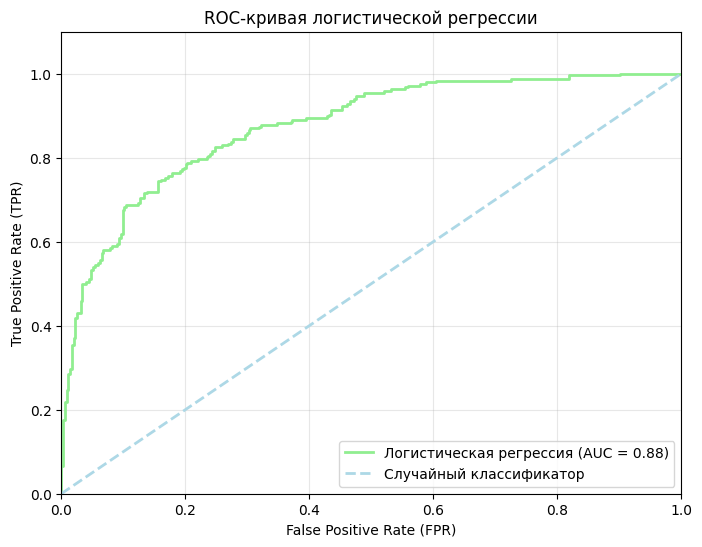

In [129]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='lightgreen', lw=2,
         label=f'Логистическая регрессия (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='lightblue', lw=2, linestyle='--',
         label='Случайный классификатор')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.1])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая логистической регрессии')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.savefig("figures/ROC_logreg.png", dpi=300, bbox_inches='tight')
plt.show()

Сравнение безлайн-модели и логистической регрессии

In [134]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
y_pred_proba_dummy = dummy.predict_proba(X_test)[:, 1]


metrics_dummy = {
    'Accuracy': accuracy_score(y_test, y_pred_dummy),
    'Precision': precision_score(y_test, y_pred_dummy, zero_division=0),
    'Recall': recall_score(y_test, y_pred_dummy, zero_division=0),
    'F1': f1_score(y_test, y_pred_dummy, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_dummy)
}

metrics_logreg = {
    'Accuracy': accuracy_val,
    'Precision': precision_val,
    'Recall': recall_val,
    'F1': f1_val,
    'ROC-AUC': roc_auc_val
}

comparison_df = pd.DataFrame({
    'DummyClassifier (most_frequent)': metrics_dummy,
    'LogisticRegression': metrics_logreg,
    'Разница (LogReg - Dummy)': {k: metrics_logreg[k] - metrics_dummy[k] for k in metrics_dummy}
})
comparison_df

,DummyClassifier (most_frequent),LogisticRegression,Разница (LogReg - Dummy)
Accuracy,0.59,0.796667,0.206667
Precision,0.00,0.748000,0.748000
Recall,0.00,0.760163,0.760163
F1,0.00,0.754032,0.754032
ROC-AUC,0.50,0.875339,0.375339


Безлайн-модель (Dummy) всегда предсказывает самый частый класс — случайное угадывание, а логистическая регрессия (LogisticRegression) анализирует взаимосвязь между признаками и целевой переменной — выявить закономерности для улучшения предсказаний. Заметим, что логистическая регрессия превосходит безлайн-модель по всем показателям, представленным в сводной таблице: accuracy выросла на 0,2, precision — на 0,75, recall — на 0,76, F1 — на 0,75, ROC-AUC — на 0,38. Тест показал, что самым оптимальным C является 10. Лучше выбрать логистическую регрессию, так как она значительно превосходит бейзлайн по всем метрикам. Также модель явно выявляет закономерности в данных и может быть использована для реальных задач. Ещё значения precision и recall находятся на близком уровне, что означает, что модель одинаково хорошо избегает ложных срабатываний